 # Artificial Intelligence Technology and Application

 ## Machine Learning Lab Guide - Student Version

 # 1 Real-Time Recommendation Practice for Retail Products

 ## 1.1 Introduction

 ### 1.1.1 About This Lab

 The recommendation system can create similarities between users and products and provide suggestions for customers based on the similarities.

 ## 1.2 Procedure

 ### 1.2.1 Preparing E-commerce Platform Data

 **Step 1: Import the required packages.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


 **Step 2: Read data.**

 Due to the absence of the raw csv file, we construct a mock dataset representing the Amazon review structure.

In [2]:
import random

# Mock Data Generation
users = [f'User_{i}' for i in range(1, 101)] # 100 users
products = [f'Prod_{i}' for i in range(1, 21)] # 20 products
data = []

for _ in range(500):
    user = random.choice(users)
    prod = random.choice(products)
    rating = random.randint(1, 5)
    timestamp = random.randint(1300000000, 1400000000)
    data.append([user, prod, rating, timestamp])

df = pd.DataFrame(data, columns=['userId', 'productId', 'Rating', 'timestamp'])

# Check Step 3: Check the data overview
print("Head of data:")
print(df.head())


Head of data:
    userId productId  Rating   timestamp
0  User_40   Prod_10       3  1391068366
1  User_84   Prod_16       1  1308247884
2  User_65   Prod_13       3  1301963049
3  User_97   Prod_11       3  1372964497
4  User_23   Prod_10       3  1362559129


 **Steps 4 & 5: View the data size and type.**

In [3]:
print("\nData Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nData Info:")
df.info()



Data Shape:
(500, 4)

Data Types:
userId         str
productId      str
Rating       int64
timestamp    int64
dtype: object

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     500 non-null    str  
 1   productId  500 non-null    str  
 2   Rating     500 non-null    int64
 3   timestamp  500 non-null    int64
dtypes: int64(2), str(2)
memory usage: 15.8 KB


 **Step 6: View the product ratings from users.**

In [4]:
print("\nRating column description:")
print(df['Rating'].describe())

print("Minimum rating:", df['Rating'].min())
print("Maximum rating:", df['Rating'].max())



Rating column description:
count    500.000000
mean       3.142000
std        1.430359
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Rating, dtype: float64
Minimum rating: 1
Maximum rating: 5


 **Steps 7 & 8: View default values and unique counts.**

In [5]:
print("\nNumber of missing values:")
print(df.isnull().sum())

print("\nTotal No of ratings:", len(df))
print("Total No of Users:", df['userId'].nunique())
print("Total No of products:", df['productId'].nunique())



Number of missing values:
userId       0
productId    0
Rating       0
timestamp    0
dtype: int64

Total No of ratings: 500
Total No of Users: 98
Total No of products: 20


 **Step 9: Delete time information.**

In [6]:
df.drop('timestamp', axis=1, inplace=True)
print("\nData after dropping timestamp:")
print(df.head())



Data after dropping timestamp:
    userId productId  Rating
0  User_40   Prod_10       3
1  User_84   Prod_16       1
2  User_65   Prod_13       3
3  User_97   Prod_11       3
4  User_23   Prod_10       3


 **Step 10: Analyze the rating data.**

In [7]:
user_counts = df.groupby('userId').size().sort_values(ascending=False)
print("\nTop Users by rating count:")
print(user_counts.head())

print("\nDescription of ratings per user:")
print(user_counts.describe())

# Display Quantiles for user ratings count
quantiles = user_counts.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
print("\nQuantiles:\n", quantiles)




Top Users by rating count:
userId
User_35    10
User_73    10
User_25     9
User_20     9
User_43     9
dtype: int64

Description of ratings per user:
count    98.000000
mean      5.102041
std       2.122485
min       1.000000
25%       4.000000
50%       5.000000
75%       6.000000
max      10.000000
dtype: float64

Quantiles:
 0.25     4.0
0.50     5.0
0.75     6.0
0.90     8.0
0.95     9.0
0.99    10.0
1.00    10.0
dtype: float64


 ### 1.2.2 Recommending Products Based on the Product Popularity

 **Steps 1 & 2: Sort products by rating frequencies and average rating.**

In [8]:
prod_counts = df.groupby('productId').size().sort_values(ascending=False)
print("\nProduct ratings frequency:\n", prod_counts.head())

prod_means = df.groupby('productId')['Rating'].mean().sort_values(ascending=False)
print("\nProduct average rating:\n", prod_means.head())

# Combine to one DataFrame
popularity_df = pd.DataFrame({
    'Rating': prod_means,
    'rating_counts': prod_counts
})
print("\nPopularity details:\n", popularity_df.head())



Product ratings frequency:
 productId
Prod_4     33
Prod_7     33
Prod_10    31
Prod_18    29
Prod_11    27
dtype: int64

Product average rating:
 productId
Prod_7     3.787879
Prod_15    3.416667
Prod_13    3.380952
Prod_12    3.368421
Prod_5     3.347826
Name: Rating, dtype: float64

Popularity details:
              Rating  rating_counts
productId                         
Prod_1     3.320000             25
Prod_10    3.225806             31
Prod_11    3.296296             27
Prod_12    3.368421             19
Prod_13    3.380952             21


 **Step 3: Visualize the result.**

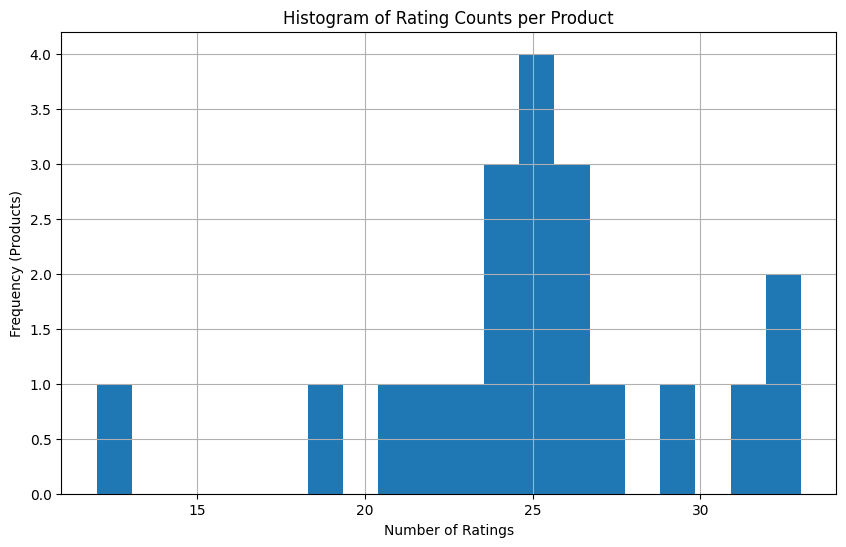

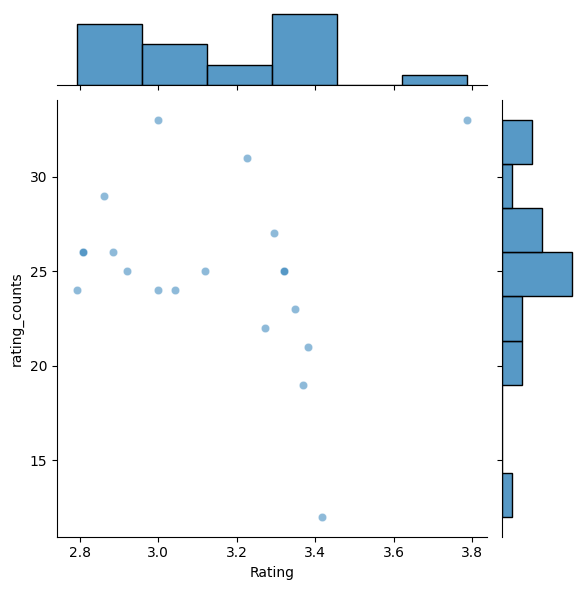

In [9]:
plt.figure(figsize=(10, 6))
popularity_df['rating_counts'].hist(bins=20)
plt.title('Histogram of Rating Counts per Product')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency (Products)')
plt.show()

# Joint Plot (Requires strictly positive distributions, demonstrating using Seaborn jointplot)
sns.jointplot(x='Rating', y='rating_counts', data=popularity_df, alpha=0.5, height=6)
plt.show()


 ### 1.2.3 Recommending Products Based on Collaborative Filtering

 **Steps 1: Create and decompose a table of relationships.**

In [10]:
# Pivot Table (Rows: features/products, Columns: users)
# We will make products rows and users columns as requested by the lab dimension references
pivot_df = df.pivot_table(index='productId', columns='userId', values='Rating').fillna(0)
print("\nPivot Table Shape:", pivot_df.shape)

# Step 2: Decompose the table using SVD
from sklearn.decomposition import TruncatedSVD

# Number of components to keep
n_components = 10 if pivot_df.shape[1] > 10 else pivot_df.shape[1] - 1
svd = TruncatedSVD(n_components=n_components, random_state=42)
product_features = svd.fit_transform(pivot_df)

print(f"Reduced Matrix Shape (Products x Encoded Features): {product_features.shape}")



Pivot Table Shape: (20, 98)
Reduced Matrix Shape (Products x Encoded Features): (20, 10)


 **Step 3 & 4: Build a correlation coefficient matrix and recommend products.**

In [11]:
corr_matrix = np.corrcoef(product_features)
print(f"\nCorrelation Matrix Shape: {corr_matrix.shape}")

# Select a random product for recommendation
product_names = pivot_df.index.tolist()
query_idx = 0 # Selecting the first product
query_product = product_names[query_idx]

print(f"\nTarget Product: {query_product}")

# Fetch correlation scores and filter > 0.65
correlations = corr_matrix[query_idx]
similar_indices = np.where(correlations > 0.65)[0]

print("Recommended Products (Corr > 0.65):")
for idx in similar_indices:
    if idx != query_idx:
        print(f"Product: {product_names[idx]} (Score: {correlations[idx]:.3f})")



Correlation Matrix Shape: (20, 20)

Target Product: Prod_1
Recommended Products (Corr > 0.65):
